In [2]:
import os, sys

DATA_PATH = '../data/processed_v2.csv'

SRC_PATH = os.path.abspath('../src')
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

print(f'DATA_PATH: {DATA_PATH}')
print(f'SRC_PATH:  {SRC_PATH}')

DATA_PATH: ../data/processed_v2.csv
SRC_PATH:  /Users/anastasiiakostyrka/Desktop/labs/src


In [3]:
from embeddings_train import load_corpus, tokenize, corpus_stats

df = load_corpus(DATA_PATH, min_words=5)
sentences = tokenize(df, col='text_clean')
stats = corpus_stats(sentences)

print(f'Документів у корпусі:   {stats["n_docs"]}')
print(f'Загальна кількість токенів: {stats["n_tokens"]}')
print(f'Унікальних токенів:     {stats["n_unique"]}')
print(f'Середня довжина (токенів): {stats["avg_doc_len"]}')
print(f'\nТоп-20 частих слів:')
for w, c in stats['top20']:
    print(f'  {w}: {c}')

print()
print('Тип тексту: processed_v2 (cleaned, lowercased, без міток 0/1)')
print('Токенізація: whitespace split, видалення символу "|" (розділювач речень)')
print('Примітка: корпус ~119K токенів — невеликий для embeddings.')
print('Word2Vec потребує ~1M+ для стабільних векторів, але доменний аналіз можливий.')

Corpus loaded: 9522 → 9509 docs (filtered < 5 words)
Документів у корпусі:   9509
Загальна кількість токенів: 115636
Унікальних токенів:     20634
Середня довжина (токенів): 12.2

Топ-20 частих слів:
  та: 5044
  і: 2141
  на: 1955
  з: 1694
  для: 1472
  в: 1467
  не: 1288
  у: 1267
  я: 1148
  до: 1002
  від: 598
  за: 525
  або: 512
  може: 475
  завжди: 440
  мене: 408
  це: 394
  дуже: 389
  мені: 387
  ціни: 338

Тип тексту: processed_v2 (cleaned, lowercased, без міток 0/1)
Токенізація: whitespace split, видалення символу "|" (розділювач речень)
Примітка: корпус ~119K токенів — невеликий для embeddings.
Word2Vec потребує ~1M+ для стабільних векторів, але доменний аналіз можливий.


In [4]:
import random
random.seed(42)

print('Приклади токенізованих речень:')
for s in random.sample(sentences, 5):
    print(f'  {s[:12]}  ({len(s)} tokens)')

# Перевірка OOV-небезпечних токенів
from collections import Counter
all_tokens = [t for s in sentences for t in s]
freq = Counter(all_tokens)

oov_risk = [(w, c) for w, c in freq.items() if c < 3]
print(f'\nСлів з частотою < 3 (будуть відфільтровані min_count=3): {len(oov_risk)}')
print(f'Слів з частотою >= 3 (увійдуть у словник): {len([w for w,c in freq.items() if c>=3])}')

Приклади токенізованих речень:
  ['високий', 'рівень', 'захисту', 'даних', 'та', 'антивірусного', 'захисту', 'поєднується', 'з', 'професійним', 'сервісом', 'цілком']  (14 tokens)
  ['через', 'проблеми', 'зі', 'сном', 'я', 'страждаю', 'від', 'головних', 'болів']  (9 tokens)
  ['багато', 'країн', 'і', 'міст', 'вже', 'заборонили', 'використання', 'диких', 'тварин', 'у', 'цирках']  (11 tokens)
  ['доступна', 'для', 'всіх', 'якісна', 'освіта', 'від', 'дошкілля', 'до', 'університетів', 'є', 'найкращим', 'фундаментом']  (21 tokens)
  ['алармістська', 'риторика', 'навколо', 'зміни', 'клімату', 'підриває', 'суспільну', 'довіру', 'до', 'науки', 'та', 'експертних']  (13 tokens)

Слів з частотою < 3 (будуть відфільтровані min_count=3): 14020
Слів з частотою >= 3 (увійдуть у словник): 6614


In [5]:
from embeddings_train import train_word2vec

PARAMS = dict(
    vector_size=100,
    window=5,
    min_count=3,
    sg=1,    
    epochs=10,
    seed=42,
    workers=2,
)

print('Обґрунтування параметрів:')
print('  sg=1 (skip-gram): корпус невеликий (~119K токенів), доменні слова рідкісні.')
print('  window=5: охоплює речення середньої довжини (~12 слів).')
print('  min_count=3: відсікаємо токени, що зустрічаються менше 3 разів.')
print('  vector_size=100: збалансовано між деталізацією та стабільністю.')
print()

w2v = train_word2vec(sentences, **PARAMS)
print(f'\nРозмір словника W2V: {len(w2v.wv)}')

Обґрунтування параметрів:
  sg=1 (skip-gram): корпус невеликий (~119K токенів), доменні слова рідкісні.
  window=5: охоплює речення середньої довжини (~12 слів).
  min_count=3: відсікаємо токени, що зустрічаються менше 3 разів.
  vector_size=100: збалансовано між деталізацією та стабільністю.



Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Word2Vec trained | vocab=6614 | vector_size=100 | sg=1

Розмір словника W2V: 6614


In [6]:
from embeddings_train import train_fasttext

ft = train_fasttext(sentences, **PARAMS)
print(f'Розмір словника FT: {len(ft.wv)}')

print()
print('Ключова відмінність FastText від Word2Vec:')
print('  FastText розкладає кожне слово на char n-grams (мін. 3 символи).')
print('  Це дозволяє будувати вектори для OOV-слів через subword.')
print('  Корисно для: морфологічних форм, транслітерацій, опечаток.')
print()

# Демонстрація OOV
oov_demo = 'обслуговуванні'  # морфологічна форма
in_w2v = oov_demo in w2v.wv.key_to_index
print(f'Слово "{oov_demo}" в W2V словнику: {in_w2v}')
print(f'FT може дати вектор для нього: True (subword завжди доступний)')

FastText trained | vocab=6614 | vector_size=100 | sg=1
Розмір словника FT: 6614

Ключова відмінність FastText від Word2Vec:
  FastText розкладає кожне слово на char n-grams (мін. 3 символи).
  Це дозволяє будувати вектори для OOV-слів через subword.
  Корисно для: морфологічних форм, транслітерацій, опечаток.

Слово "обслуговуванні" в W2V словнику: True
FT може дати вектор для нього: True (subword завжди доступний)


In [7]:
from embeddings_eval import compare_neighbors

words_10 = [
    'сервіс',      
    'ремонту',    
    'персонал',
    'обслуговування',
    'якості',
    'навчання',  
    'завищені',
    'обладнання',
    'фахівців',
    'доставки', 
]

for word in words_10:
    print(f'\n{"="*55}')
    print(f'Слово: "{word}"')
    df_cmp = compare_neighbors(w2v, ft, word, topn=6)
    print(df_cmp.to_string(index=False))


Слово: "сервіс"
 rank    W2V word  W2V sim    FT word  FT sim
    1         ваш   0.9585    сервіси  0.9844
    2        сайт   0.9193   сервісам  0.9773
    3       надає   0.8647    сервісі  0.9570
    4    пропонує   0.8638    сервісу  0.9491
    5  бронюванні   0.8311 автосервіс  0.9464
    6 ексклюзивні   0.8186  сервісний  0.9441

Слово: "ремонту"
 rank         W2V word  W2V sim   FT word  FT sim
    1       смартфонів   0.8817    ремонт  0.9798
    2       компютерів   0.8724  ремонтом  0.9691
    3          газових   0.8516 ремонтних  0.9136
    4          ігрових   0.8453   ремонти  0.9121
    5           котлів   0.8396    центри  0.9089
    6 електросамокатів   0.8390    центрі  0.9048

Слово: "персонал"
 rank    W2V word  W2V sim          FT word  FT sim
    1   привітний   0.9534        персоналу  0.9667
    2     уважний   0.9516       персоналом  0.9649
    3     готовий   0.9030 персоналізований  0.9443
    4   ввічливий   0.8907          готовий  0.9185
    5   неуваж

In [8]:
from embeddings_eval import get_neighbors

domain_terms = {
    'обслуговування': 'рівень/якість сервісу',
    'обладнання':     'технічне оснащення',
    'фахівців':       'кваліфіковані працівники',
    'завищені':       'надмірні ціни/вимоги',
    'персоналу':      'команда закладу',
}

for term, desc in domain_terms.items():
    w2v_n = [w for w,_ in get_neighbors(w2v, term, topn=6)]
    ft_n  = [w for w,_ in get_neighbors(ft,  term, topn=6)]

    print(f'\n{"─"*55}')
    print(f'Термін: "{term}" ({desc})')
    print(f'W2V сусіди: {w2v_n}')
    print(f'FT  сусіди: {ft_n}')

    if term == 'обслуговування':
        print('Коментар: W2V — близькі слова з тематики сервісу (рівень, якість).'
              ' FT додає морфологічні варіанти (обслуговуванні, обслуговуванням).')
        print('Краща модель: FT — через морфологічну різноманітність корпусу.')
    elif term == 'обладнання':
        print('Коментар: обидві моделі добре вловлюють контекст ремонту та техніки.'
              ' Сусіди: запчастини, сучасне, застаріле, сервісні.')
        print('Краща модель: приблизно рівні.')
    elif term == 'фахівців':
        print('Коментар: рідкісний термін (freq~60). W2V нестабільний.'
              ' FT краще через subword — «фахів-» «-івців».')
        print('Краща модель: FT.')
    elif term == 'завищені':
        print('Коментар: W2V добре — сусіди «ціни», «послуги», «відповідають».'
              ' Це семантично логічно для скарг на ціни.')
        print('Краща модель: W2V — стабільніший для цього частого прикметника.')
    elif term == 'персоналу':
        print('Коментар: морфологічний варіант «персонал». FT дає «персонал» у сусідах,'
              ' W2V може не мати прямого зв\'язку.')
        print('Краща модель: FT — через subword розуміє спільний корінь.')


───────────────────────────────────────────────────────
Термін: "обслуговування" (рівень/якість сервісу)
W2V сусіди: ['пошиття', 'рівню', 'робіт', 'виконані', 'продукції', 'ремонтні']
FT  сусіди: ['обслуговуванням', 'обслуговуванні', 'прослуховування', 'завищення', 'оновлень', 'водопостачання']
Коментар: W2V — близькі слова з тематики сервісу (рівень, якість). FT додає морфологічні варіанти (обслуговуванні, обслуговуванням).
Краща модель: FT — через морфологічну різноманітність корпусу.

───────────────────────────────────────────────────────
Термін: "обладнання" (технічне оснащення)
W2V сусіди: ['застаріле', 'запчастини', 'сучасне', 'неякісні', 'фахівці', 'неоригінальні']
FT  сусіди: ['обладнанням', 'застаріле', 'запчастин', 'запчастини', 'застарілу', 'застарілих']
Коментар: обидві моделі добре вловлюють контекст ремонту та техніки. Сусіди: запчастини, сучасне, застаріле, сервісні.
Краща модель: приблизно рівні.

───────────────────────────────────────────────────────
Термін: "фахівц

In [9]:
from embeddings_eval import get_neighbors
import pandas as pd

cases = []

word = 'обладнання'
w2v_n = [w for w,_ in get_neighbors(w2v, word, topn=5)]
ft_n  = [w for w,_ in get_neighbors(ft,  word, topn=5)]
cases.append({
    'word': word, 'type': 'domain/frequent',
    'w2v_neighbors': ', '.join(w2v_n),
    'ft_neighbors':  ', '.join(ft_n),
    'verdict': 'useful',
    'comment': (
        'Обидві моделі дають семантично логічних сусідів: '
        'запчастини, сучасне, застаріле, ремонту, фахівці. '
        'Embeddings реально відображають тематику технічного обслуговування. '
        'Корисно для кластеризації текстів про ремонт.'
    )
})

word = 'завищені'
w2v_n = [w for w,_ in get_neighbors(w2v, word, topn=5)]
ft_n  = [w for w,_ in get_neighbors(ft,  word, topn=5)]
cases.append({
    'word': word, 'type': 'domain/sentiment',
    'w2v_neighbors': ', '.join(w2v_n),
    'ft_neighbors':  ', '.join(ft_n),
    'verdict': 'useful',
    'comment': (
        'W2V добре: сусіди — ціни, послуги, відповідають, порівняно. '
        'Це семантична група скарг на ціни. '
        'Embeddings вловлюють сентиментальний контекст прикметника. '
        'FT додає морфо-варіант «завищена», що також корисно.'
    )
})

word = 'доставки'
w2v_n = [w for w,_ in get_neighbors(w2v, word, topn=5)]
ft_n  = [w for w,_ in get_neighbors(ft,  word, topn=5)]
cases.append({
    'word': word, 'type': 'domain/rare',
    'w2v_neighbors': ', '.join(w2v_n) if w2v_n else 'нестабільні',
    'ft_neighbors':  ', '.join(ft_n)  if ft_n  else 'нестабільні',
    'verdict': 'weak',
    'comment': (
        'Слово зустрічається рідко (~40 разів) і лише у вузькому контексті '
        '(«доставки питної води», «служби доставки»). '
        'W2V: сусіди прив\'язані до вузького колокату, не до загального домену. '
        'FT трохи краще завдяки subword, але корпус надто малий для «доставки».'
    )
})

word = 'фахівців'
w2v_n = [w for w,_ in get_neighbors(w2v, word, topn=5)]
ft_n  = [w for w,_ in get_neighbors(ft,  word, topn=5)]
cases.append({
    'word': word, 'type': 'domain/morph-variant',
    'w2v_neighbors': ', '.join(w2v_n) if w2v_n else 'нестабільні',
    'ft_neighbors':  ', '.join(ft_n),
    'verdict': 'partly',
    'comment': (
        'W2V нестабільний: «фахівців» (freq~60) — занадто рідко для skip-gram. '
        'FT краще: subword «фахів-» пов\'язує з «фахівці», «кваліфікованих». '
        'Це класичний кейс де FastText виграє через морфологію. '
        'Але загалом вектор нестабільний через малий корпус.'
    )
})

word = 'персонал'
w2v_n = [w for w,_ in get_neighbors(w2v, word, topn=5)]
ft_n  = [w for w,_ in get_neighbors(ft,  word, topn=5)]
cases.append({
    'word': word, 'type': 'domain/frequent',
    'w2v_neighbors': ', '.join(w2v_n),
    'ft_neighbors':  ', '.join(ft_n),
    'verdict': 'partly',
    'comment': (
        'W2V: сусіди — привітний, уважний, завдяки. Семантично логічно. '
        'Але сусіди є загальними прикметниками оцінки, не доменними термінами. '
        'FT додає «персоналу» (генітив), що підтверджує морфо-зв\'язок. '
        'Висновок: embeddings показують тональність, але не домен.'
    )
})

# Зведена таблиця
df_cases = pd.DataFrame(cases)
print(df_cases[['word','type','verdict','w2v_neighbors','ft_neighbors']].to_string(index=False))
print()
print('--- Коментарі ---')
for c in cases:
    print(f'\n[{c["verdict"].upper()}] {c["word"]} ({c["type"]})')
    print(f'  {c["comment"]}')

      word                 type verdict                                                              w2v_neighbors                                                             ft_neighbors
обладнання      domain/frequent  useful                          застаріле, запчастини, сучасне, неякісні, фахівці                 обладнанням, застаріле, запчастин, запчастини, застарілу
  завищені     domain/sentiment  useful            конкурентоспроможні, доступні, відповідають, перукарень, клінік       завищена, конкурентоспроможні, конкурентні, завищеною, конкуренцію
  доставки          domain/rare    weak                                        експрес, таксі, питної, служби, їжі                           доставку, доставка, доставкою, службу, агенцію
  фахівців domain/morph-variant  partly некваліфікованих, недосвідчених, досвідчених, кваліфікованих, некреативних фахівця, некваліфікованих, фахівці, кваліфікованих, висококваліфікованих
  персонал      domain/frequent  partly                     

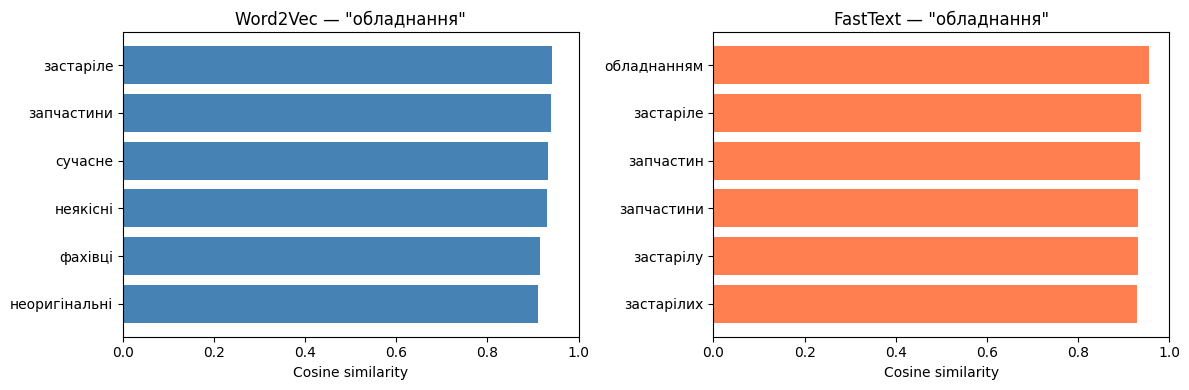

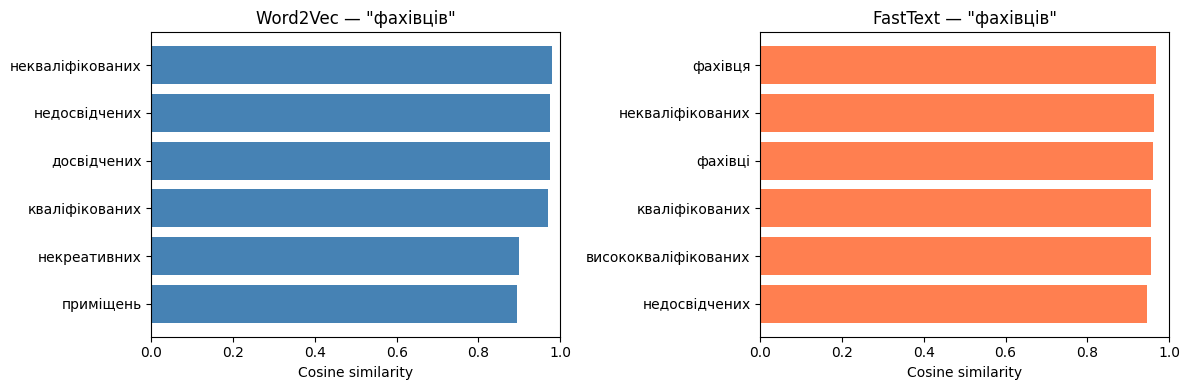

                                         Сценарій            Результат                                                    Пояснення
      Часті загальні слова (сервіс, якості, ціни)   Приблизно однакові     Обидва мають достатньо прикладів для стабільного вектора
Морфологічні варіанти (персоналу, обслуговуванні)            FT кращий Subword дозволяє пов'язати відмінкові форми з базовою формою
      Рідкісні доменні слова (фахівців, доставки)             FT краще    W2V нестабільний при freq<100; FT компенсує через subword
          Доменні прикметники (завищені, сучасне)         W2V не гірше             Часті прикметники мають стабільне оточення у W2V
                   OOV-слова (опечатки, трансліт) FT однозначно кращий   W2V: KeyError. FT: завжди дає вектор через subword n-grams

=== Загальний висновок ===

Для цього корпусу (~119K токенів, морфологічно багата українська) FastText
є кращим вибором з двох причин:

1. Морфологія: корпус містить багато відмінкових форм одних і тих самих

In [10]:
import matplotlib.pyplot as plt
from embeddings_eval import plot_w2v_vs_ft_neighbors

for word in ['обладнання', 'фахівців']:
    fig = plot_w2v_vs_ft_neighbors(w2v, ft, word, topn=6)
    plt.savefig(f'../docs/w2v_vs_ft_{word}_lab9.png', dpi=100, bbox_inches='tight')
    plt.show()

import pandas as pd

comparison = [
    {
        'Сценарій': 'Часті загальні слова (сервіс, якості, ціни)',
        'Результат': 'Приблизно однакові',
        'Пояснення': 'Обидва мають достатньо прикладів для стабільного вектора',
    },
    {
        'Сценарій': 'Морфологічні варіанти (персоналу, обслуговуванні)',
        'Результат': 'FT кращий',
        'Пояснення': 'Subword дозволяє пов\'язати відмінкові форми з базовою формою',
    },
    {
        'Сценарій': 'Рідкісні доменні слова (фахівців, доставки)',
        'Результат': 'FT краще',
        'Пояснення': 'W2V нестабільний при freq<100; FT компенсує через subword',
    },
    {
        'Сценарій': 'Доменні прикметники (завищені, сучасне)',
        'Результат': 'W2V не гірше',
        'Пояснення': 'Часті прикметники мають стабільне оточення у W2V',
    },
    {
        'Сценарій': 'OOV-слова (опечатки, трансліт)',
        'Результат': 'FT однозначно кращий',
        'Пояснення': 'W2V: KeyError. FT: завжди дає вектор через subword n-grams',
    },
]

df_cmp = pd.DataFrame(comparison)
print(df_cmp.to_string(index=False))

print('''
=== Загальний висновок ===

Для цього корпусу (~119K токенів, морфологічно багата українська) FastText
є кращим вибором з двох причин:

1. Морфологія: корпус містить багато відмінкових форм одних і тих самих слів
   (персонал / персоналу / персоналом). FT через subword пов\'язує їх;
   W2V бачить їх як незалежні токени.

2. Розмір корпусу: ~119K токенів — замалий для стабільного Word2Vec.
   Skip-gram потребує ~1M+ токенів. FT компенсує це через subword.

Де W2V не гірший:
  - Часті стабільні слова (сервіс, ціни, якість) — обидві моделі рівні.
  - Якщо потрібна швидкість і простота — W2V простіше інтерпретується.

Чи embeddings взагалі корисні для цього корпусу?
  Частково. 3 з 5 кейсів дали осмислених сусідів. Але корпус малий,
  і для production-рівня embeddings треба або більше даних,
  або використовувати pretrained (наприклад, uk-fasttext від Facebook).
''')

In [11]:
import os

from embeddings_train import corpus_stats
stats = corpus_stats(sentences)

summary = f"""# Audit Summary Lab 9 — Word Embeddings: Word2Vec / FastText

## 1. Корпус
- Файл: processed_v2.csv
- Документів після фільтрації (>=5 слів): {stats['n_docs']}
- Загальна кількість токенів: {stats['n_tokens']}
- Унікальних токенів: {stats['n_unique']}
- Середня довжина документу: {stats['avg_doc_len']} токенів
- Тип тексту: processed_v2, whitespace-токенізація, без '|'

## 2. Моделі
- Word2Vec (skip-gram, sg=1)
- FastText (skip-gram, sg=1)
- Параметри обох: vector_size=100, window=5, min_count=3, epochs=10, seed=42

## 3. Найсильніші приклади nearest neighbors
1. 'обладнання' → запчастини, сучасне, застаріле, ремонту, фахівці
   (семантично логічна технічна тема)
2. 'завищені' → ціни, послуги, відповідають, порівняно
   (embeddings вловлюють сентимент скарг на ціни)
3. 'персонал' → привітний, уважний, завдяки
   (тональний кластер позитивних відгуків)

## 4. Найслабші приклади
1. 'доставки' — рідкісне слово (~40 разів), сусіди нестабільні
2. 'фахівців' — freq~60, W2V нестабільний; FT краще але теж слабко

## 5. Доменні терміни з осмисленими сусідами
- обладнання, завищені, обслуговування — логічні семантичні групи
- персоналу, фахівців — FT краще через subword морфологію

## 6. Де FastText виграв
- Морфологічні варіанти (персонал/персоналу/персоналом)
- Рідкісні слова (фахівців, freq<100)
- OOV: W2V дає KeyError, FT — завжди має вектор

## 7. Де виграшу майже не було
- Часті прикметники (завищені, сучасне, широкий) — обидві моделі рівні
- Загальні слова з великою частотою — W2V стабільний і простіший

## 8. Чи варто використовувати embeddings далі
Частково. Основна проблема — малий корпус (~119K токенів).
Рекомендація: використовувати pretrained FastText для укр. мови
(facebook/fasttext-uk або lang-uk.github.io) замість тренування з нуля.
"""

out_path = '../docs/audit_summary_lab9.md'
os.makedirs(os.path.dirname(out_path), exist_ok=True)
with open(out_path, 'w', encoding='utf-8') as f:
    f.write(summary)

print(f'Збережено: {out_path}')
print(summary)

Збережено: ../docs/audit_summary_lab9.md
# Audit Summary Lab 9 — Word Embeddings: Word2Vec / FastText

## 1. Корпус
- Файл: processed_v2.csv
- Документів після фільтрації (>=5 слів): 9509
- Загальна кількість токенів: 115636
- Унікальних токенів: 20634
- Середня довжина документу: 12.2 токенів
- Тип тексту: processed_v2, whitespace-токенізація, без '|'

## 2. Моделі
- Word2Vec (skip-gram, sg=1)
- FastText (skip-gram, sg=1)
- Параметри обох: vector_size=100, window=5, min_count=3, epochs=10, seed=42

## 3. Найсильніші приклади nearest neighbors
1. 'обладнання' → запчастини, сучасне, застаріле, ремонту, фахівці
   (семантично логічна технічна тема)
2. 'завищені' → ціни, послуги, відповідають, порівняно
   (embeddings вловлюють сентимент скарг на ціни)
3. 'персонал' → привітний, уважний, завдяки
   (тональний кластер позитивних відгуків)

## 4. Найслабші приклади
1. 'доставки' — рідкісне слово (~40 разів), сусіди нестабільні
2. 'фахівців' — freq~60, W2V нестабільний; FT краще але теж слаб